In [96]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

print(tensorflow.__version__)

2.6.0


# STEP 1. 데이터 수집

In [10]:
# CSV 파일 경로 설정
file_path = './data/ChatbotData .csv'

# CSV 파일 읽어오기
try:
    chatbot_data = pd.read_csv(file_path)
    print("CSV 파일 읽기 성공!")
except FileNotFoundError:
    print(f"오류: '{file_path}' 파일을 찾을 수 없습니다. 파일 경로를 확인해주세요.")
    chatbot_data = None

if chatbot_data is not None:
    # 데이터 확인 - 처음 5행 출력
    print("\n--- 데이터 샘플 (처음 5행) ---")
    print(chatbot_data.head())

    # 데이터 정보 요약
    print("\n--- 데이터 정보 요약 ---")
    print(chatbot_data.info())

    # 기술 통계 정보
    print("\n--- 기술 통계 정보 ---")
    print(chatbot_data.describe(include='all'))

    # 결측치 확인
    print("\n--- 결측치 확인 ---")
    print(chatbot_data.isnull().sum())

    # 중복 데이터 확인
    print("\n--- 중복 데이터 확인 ---")
    print(chatbot_data.duplicated().sum())

    # 'label' 컬럼의 고유값 및 빈도 확인 (분류 문제인 경우)
    if 'label' in chatbot_data.columns:
        print("\n--- 'label' 컬럼 고유값 및 빈도 ---")
        print(chatbot_data['label'].value_counts())

CSV 파일 읽기 성공!

--- 데이터 샘플 (처음 5행) ---
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0

--- 데이터 정보 요약 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB
None

--- 기술 통계 정보 ---
            Q         A         label
count   11823     11823  11823.000000
unique  11662      7779           NaN
top       외로워  맛있게 드세요.           NaN
freq        4        22           NaN
mean      NaN       NaN      0.803180
std       NaN       NaN      0.812012
min       NaN       NaN      0.000000
25%       NaN       NaN      0.000000
50% 

## 챗봇 트레이닝 데이터셋 정보 요약

**데이터셋 크기:** 11,823개 문답 페어

**레이블 정보:**

*   **레이블 종류:** 3가지
    *   **0:** 일상다반사
    *   **1:** 이별 (부정)
    *   **2:** 사랑 (긍정)
*   **레이블링 기준:** 문맥 및 감정 (일상 대화, 이별 관련 부정적 감정, 사랑 관련 긍정적 감정)

# STEP 2. 데이터 전처리
## 필수 전처리:
- 텍스트 정제: 특수 문자, 숫자, 문장 부호 제거 또는 정규화 (예: ?!., -> 공백으로 치환). 필요에 따라 이모티콘 처리.
- 띄어쓰기 정규화: 불필요한 띄어쓰기 제거, 여러 개의 공백을 하나로 축소

In [148]:
# 텍스트 정제 함수 정의
def clean_text(text):
    # 특수 문자, 숫자, 문장 부호 제거 (한글, 영문, 공백만 남김)
    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", "", text)
    # 필요에 따라 이모티콘 제거 (더욱 엄격한 정제가 필요하면 이모티콘 제거 패턴 추가)
    text = re.sub(r"[\U00010000-\U0010ffff]", "", text) # Supp. Multilingual Plane 제거
    text = re.sub(r"[\uD800-\uDBFF][\uDC00-\uDFFF]", "", text) # Surrogates 제거
    return text

# 띄어쓰기 정규화 함수 정의
def normalize_whitespace(text):
    # 여러 개의 공백을 하나의 공백으로 축소
    text = re.sub(r'\s+', ' ', text)
    # 문장 시작과 끝의 공백 제거
    text = text.strip()
    return text

def preprocess_sentence(sentence):
    sentence = clean_text(sentence)
    sentence = normalize_whitespace(sentence)
    return sentence

In [12]:
# 'Q' 컬럼 텍스트 정제 및 띄어쓰기 정규화 적용
chatbot_data['Q'] = chatbot_data['Q'].apply(clean_text)
chatbot_data['Q'] = chatbot_data['Q'].apply(normalize_whitespace)

# 'A' 컬럼 텍스트 정제 및 띄어쓰기 정규화 적용
chatbot_data['A'] = chatbot_data['A'].apply(clean_text)
chatbot_data['A'] = chatbot_data['A'].apply(normalize_whitespace)

# 전처리 후 데이터 샘플 확인 (처음 5행)
print("\n--- 전처리 후 데이터 샘플 (처음 5행) ---")
print(chatbot_data.head())


--- 전처리 후 데이터 샘플 (처음 5행) ---
                 Q           A  label
0            12시 땡   하루가 또 가네요      0
1      1지망 학교 떨어졌어    위로해 드립니다      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠      0
4          PPL 심하네   눈살이 찌푸려지죠      0


# Step 3. 데이터셋 생성

In [169]:
# SubwordTextEncoder 생성 및 vocabulary 빌드
tokenizer = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(
    corpus_generator=(text for text_list in [chatbot_data['Q'], chatbot_data['A']] for text in text_list), # Q, A 컬럼 텍스트를 corpus로 사용
    target_vocab_size=2**13 # vocabulary 크기를 8192 (2^13) 로 설정 (조정 가능)
)

# SubwordTextEncoder vocabulary 크기 확인
print("\n--- SubwordTextEncoder Vocabulary 크기 ---")
print(tokenizer.vocab_size)

# 'Q' 컬럼을 SubwordTextEncoder를 사용하여 정수 인코딩
chatbot_data['Q_encoded'] = chatbot_data['Q'].apply(lambda text: tokenizer.encode(text))

# 'A' 컬럼을 SubwordTextEncoder를 사용하여 정수 인코딩
chatbot_data['A_encoded'] = chatbot_data['A'].apply(lambda text: tokenizer.encode(text))

# 인코딩된 데이터 샘플 확인 (처음 5행, Q, Q_encoded, A, A_encoded 컬럼만 출력)
print("\n--- 인코딩된 데이터 샘플 (처음 5행) ---")
print(chatbot_data[['Q', 'Q_encoded', 'A', 'A_encoded']].head())

VOCAB_SAVE_PATH = './vocab_chatbot' # 저장 경로 및 파일 이름 설정 (원하는 경로로 변경 가능)
tokenizer.save_to_file(VOCAB_SAVE_PATH)


--- SubwordTextEncoder Vocabulary 크기 ---
8177

--- 인코딩된 데이터 샘플 (처음 5행) ---
                 Q                                 Q_encoded           A  \
0            12시 땡                        [7918, 2567, 3057]   하루가 또 가네요   
1      1지망 학교 떨어졌어          [7970, 43, 911, 7953, 987, 1707]    위로해 드립니다   
2     3박4일 놀러가고 싶다        [7972, 1425, 4648, 7953, 3641, 63]  여행은 언제나 좋죠   
3  3박4일 정도 놀러가고 싶다  [7972, 1425, 4648, 7953, 1284, 3641, 63]  여행은 언제나 좋죠   
4          PPL 심하네            [8001, 8001, 7997, 7953, 4180]   눈살이 찌푸려지죠   

                           A_encoded  
0                   [3832, 71, 7897]  
1                       [1824, 5497]  
2                   [3390, 767, 125]  
3                   [3390, 767, 125]  
4  [976, 2289, 1486, 2172, 5464, 46]  


In [156]:
MAX_LENGTH = 40
START_TOKEN_INDEX = tokenizer.vocab_size  # START_TOKEN index를 vocabulary 크기로 설정
END_TOKEN_INDEX = tokenizer.vocab_size + 1 # END_TOKEN index를 vocabulary 크기 + 1로 설정
START_TOKEN, END_TOKEN = [tokenizer.vocab_size], [tokenizer.vocab_size + 1]

print("\n--- START_TOKEN_INDEX, END_TOKEN_INDEX ---")
print(START_TOKEN_INDEX)
print(END_TOKEN_INDEX)

questions_encoded = []
answers_encoded = []

# START_TOKEN 및 END_TOKEN 추가, MAX_LENGTH 초과 문장 필터링
for q_encoded, a_encoded in zip(chatbot_data['Q_encoded'], chatbot_data['A_encoded']):
    q_encoded_with_tokens = [START_TOKEN_INDEX] + q_encoded + [END_TOKEN_INDEX]
    a_encoded_with_tokens = [START_TOKEN_INDEX] + a_encoded + [END_TOKEN_INDEX]

    if len(q_encoded_with_tokens) <= MAX_LENGTH and len(a_encoded_with_tokens) <= MAX_LENGTH:
        questions_encoded.append(q_encoded_with_tokens)
        answers_encoded.append(a_encoded_with_tokens)

print("\n--- 필터링 및 START_TOKEN, END_TOKEN 추가 후 데이터 개수 ---")
print("questions_encoded 개수:", len(questions_encoded))
print("answers_encoded 개수:", len(answers_encoded))

# Padding
questions_padded = tf.keras.preprocessing.sequence.pad_sequences(
    questions_encoded,
    maxlen=MAX_LENGTH,
    padding='post',
    value=0) # padding value 명시적으로 0으로 지정

answers_padded = tf.keras.preprocessing.sequence.pad_sequences(
    answers_encoded,
    maxlen=MAX_LENGTH,
    padding='post',
    value=0) # padding value 명시적으로 0으로 지정

# numpy array 로 변환
questions = np.array(questions_padded)
answers = np.array(answers_padded)

print("\n--- questions, answers shape 확인 ---")
print(questions.shape)
print(answers.shape)

# dataset 생성 및 셔플링, 배치 적용 (tf.data.Dataset.from_tensor_slices 사용)
BUFFER_SIZE = len(questions)
BATCH_SIZE = 64 # 배치 사이즈 (조정 가능)

dataset = tf.data.Dataset.from_tensor_slices((
    {
        'inputs': questions,
        'dec_inputs': answers[:, :-1] # 디코더 입력: <start> 토큰 제거 (target 문장 앞부분)
    },
    {
        'outputs': answers[:, 1:]  # 디코더 출력: <end> 토큰 제거 (target 문장 뒷부분)
    },
))

dataset = dataset.cache()
dataset = dataset.shuffle(BUFFER_SIZE)
dataset = dataset.padded_batch(BATCH_SIZE, padding_values=0) # padded_batch에는 padding_values 인자 불필요, 이미 padding 완료
dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)

print("\n--- dataset 생성 완료 ---")

# 생성된 dataset 샘플 출력 (1개 배치만 확인)
print("\n--- 생성된 dataset 샘플 (1 배치) ---")
for sample_inputs, sample_outputs in dataset.take(1):
    print("샘플 입력 (inputs):", sample_inputs['inputs'].shape)
    print("샘플 입력 (dec_inputs):", sample_inputs['dec_inputs'].shape)
    print("샘플 출력 (outputs):", sample_outputs['outputs'].shape)


--- START_TOKEN_INDEX, END_TOKEN_INDEX ---
8177
8178

--- 필터링 및 START_TOKEN, END_TOKEN 추가 후 데이터 개수 ---
questions_encoded 개수: 11823
answers_encoded 개수: 11823

--- questions, answers shape 확인 ---
(11823, 40)
(11823, 40)

--- dataset 생성 완료 ---

--- 생성된 dataset 샘플 (1 배치) ---
샘플 입력 (inputs): (64, 40)
샘플 입력 (dec_inputs): (64, 39)
샘플 출력 (outputs): (64, 39)


# Step 4. 모델 구성 (Transformer)

In [128]:
VOCAB_SIZE = 8192  # 이전 STEP 3 결과에 따라 변경해야 합니다.

# Hyperparameters (조정 가능)
NUM_LAYERS = 2 # 인코더와 디코더의 층의 개수
D_MODEL = 256 # 인코더와 디코더 내부의 입, 출력의 고정 차원
NUM_HEADS = 8 # 멀티 헤드 어텐션에서의 헤드 수
UNITS = 512 # 피드 포워드 신경망의 은닉층의 크기
DROPOUT = 0.1 # 드롭아웃의 비율
MAX_LENGTH = 40 # 최대 문장 길이 (필요에 따라 조정)

In [147]:
# 포지셔널 인코딩 레이어
class PositionalEncoding(tf.keras.layers.Layer):

  def __init__(self, position, d_model):
    super(PositionalEncoding, self).__init__()
    self.pos_encoding = self.positional_encoding(position, d_model)

  def get_angles(self, position, i, d_model):
    angles = 1 / tf.pow(10000, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
    return position * angles

  def positional_encoding(self, position, d_model):
    # 각도 배열 생성
    angle_rads = self.get_angles(
        position=tf.range(position, dtype=tf.float32)[:, tf.newaxis],
        i=tf.range(d_model, dtype=tf.float32)[tf.newaxis, :],
        d_model=d_model)

    # 배열의 짝수 인덱스에는 sin 함수 적용
    sines = tf.math.sin(angle_rads[:, 0::2])
    # 배열의 홀수 인덱스에는 cosine 함수 적용
    cosines = tf.math.cos(angle_rads[:, 1::2])

    # sin과 cosine이 교차되도록 재배열
    pos_encoding = tf.stack([sines, cosines], axis=0)
    pos_encoding = tf.transpose(pos_encoding,[1, 2, 0]) 
    pos_encoding = tf.reshape(pos_encoding, [position, d_model])

    pos_encoding = pos_encoding[tf.newaxis, ...]
    return tf.cast(pos_encoding, tf.float32)

  def call(self, inputs):
    return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

print("슝=3")

슝=3


In [129]:
# 스케일드 닷 프로덕트 어텐션 함수
def scaled_dot_product_attention(query, key, value, mask):
  # 어텐션 가중치는 Q와 K의 닷 프로덕트
  matmul_qk = tf.matmul(query, key, transpose_b=True)

  # 가중치를 정규화
  depth = tf.cast(tf.shape(key)[-1], tf.float32)
  logits = matmul_qk / tf.math.sqrt(depth)

  # 패딩에 마스크 추가
  if mask is not None:
    logits += (mask * -1e9)

  # softmax적용
  attention_weights = tf.nn.softmax(logits, axis=-1)

  # 최종 어텐션은 가중치와 V의 닷 프로덕트
  output = tf.matmul(attention_weights, value)
  return output

In [130]:
class MultiHeadAttention(tf.keras.layers.Layer):

  def __init__(self, d_model, num_heads, name="multi_head_attention"):
    super(MultiHeadAttention, self).__init__(name=name)
    self.num_heads = num_heads
    self.d_model = d_model

    assert d_model % self.num_heads == 0

    self.depth = d_model // self.num_heads

    self.query_dense = tf.keras.layers.Dense(units=d_model)
    self.key_dense = tf.keras.layers.Dense(units=d_model)
    self.value_dense = tf.keras.layers.Dense(units=d_model)

    self.dense = tf.keras.layers.Dense(units=d_model)

  def split_heads(self, inputs, batch_size):
    inputs = tf.reshape(
        inputs, shape=(batch_size, -1, self.num_heads, self.depth))
    return tf.transpose(inputs, perm=[0, 2, 1, 3])

  def call(self, inputs):
    query, key, value, mask = inputs['query'], inputs['key'], inputs[
        'value'], inputs['mask']
    batch_size = tf.shape(query)[0]

    # Q, K, V에 각각 Dense를 적용합니다 (user code의 빈칸 채우기)
    query = self.query_dense(query) # [[YOUR CODE]] -> self.query_dense(query)
    key = self.key_dense(key) # [[YOUR CODE]] -> self.key_dense(key)
    value = self.value_dense(value) # [[YOUR CODE]] -> self.value_dense(value)

    # 병렬 연산을 위한 머리를 여러 개 만듭니다 (user code의 빈칸 채우기)
    query = self.split_heads(query, batch_size) # [[YOUR CODE]] -> self.split_heads(query, batch_size)
    key = self.split_heads(key, batch_size) # [[YOUR CODE]] -> self.split_heads(key, batch_size)
    value = self.split_heads(value, batch_size) # [[YOUR CODE]] -> self.split_heads(value, batch_size)
    # 스케일드 닷 프로덕트 어텐션 함수
    scaled_attention = scaled_dot_product_attention(query, key, value, mask)

    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])

    # 어텐션 연산 후에 각 결과를 다시 연결(concatenate)합니다
    concat_attention = tf.reshape(scaled_attention,
                                  (batch_size, -1, self.d_model))

    # 최종 결과에도 Dense를 한 번 더 적용합니다
    outputs = self.dense(concat_attention)

    return outputs
print("슝=3")

슝=3


In [131]:
# 마스크 함수
def create_padding_mask(x):
  mask = tf.cast(tf.math.equal(x, 0), tf.float32)
  # (batch_size, 1, 1, sequence length)
  return mask[:, tf.newaxis, tf.newaxis, :]
print("슝=3")
print(create_padding_mask(tf.constant([[1, 2, 0, 3, 0], [0, 0, 0, 4, 5]])))

슝=3
tf.Tensor(
[[[[0. 0. 1. 0. 1.]]]


 [[[1. 1. 1. 0. 0.]]]], shape=(2, 1, 1, 5), dtype=float32)


In [132]:
def create_look_ahead_mask(x):
  seq_len = tf.shape(x)[1]
  look_ahead_mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
  padding_mask = create_padding_mask(x)
  return tf.maximum(look_ahead_mask, padding_mask)
print("슝=3")
print(create_look_ahead_mask(tf.constant([[0, 5, 1, 5, 5]])))

슝=3
tf.Tensor(
[[[[1. 1. 1. 1. 1.]
   [1. 0. 1. 1. 1.]
   [1. 0. 0. 1. 1.]
   [1. 0. 0. 0. 1.]
   [1. 0. 0. 0. 0.]]]], shape=(1, 1, 5, 5), dtype=float32)


In [133]:
# 인코더 하나의 레이어를 함수로 구현.
# 이 하나의 레이어 안에는 두 개의 서브 레이어가 존재합니다.
def encoder_layer(units, d_model, num_heads, dropout, name="encoder_layer"):
  inputs = tf.keras.Input(shape=(None, d_model), name="inputs")

  # 패딩 마스크 사용
  padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

  # 첫 번째 서브 레이어 : 멀티 헤드 어텐션 수행 (셀프 어텐션)
  attention = MultiHeadAttention(
      d_model, num_heads, name="attention")({
          'query': inputs,
          'key': inputs,
          'value': inputs,
          'mask': padding_mask
      })

  # 어텐션의 결과는 Dropout과 Layer Normalization이라는 훈련을 돕는 테크닉을 수행
  attention = tf.keras.layers.Dropout(rate=dropout)(attention)
  attention = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(inputs + attention)

  # 두 번째 서브 레이어 : 2개의 완전연결층
  outputs = tf.keras.layers.Dense(units=units, activation='relu')(attention)
  outputs = tf.keras.layers.Dense(units=d_model)(outputs)

  # 완전연결층의 결과는 Dropout과 LayerNormalization이라는 훈련을 돕는 테크닉을 수행
  outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
  outputs = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(attention + outputs)

  return tf.keras.Model(
      inputs=[inputs, padding_mask], outputs=outputs, name=name)
print("슝=3")

슝=3


In [134]:
def encoder(vocab_size,
            num_layers,
            units,
            d_model,
            num_heads,
            dropout,
            name="encoder"):
  inputs = tf.keras.Input(shape=(None,), name="inputs")

  # 패딩 마스크 사용
  padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

  # 임베딩 레이어
  embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
  embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))

  # 포지셔널 인코딩
  embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)

  outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

  # num_layers만큼 쌓아올린 인코더의 층.
  for i in range(num_layers):
    outputs = encoder_layer(
        units=units,
        d_model=d_model,
        num_heads=num_heads,
        dropout=dropout,
        name="encoder_layer_{}".format(i),
    )([outputs, padding_mask])

  return tf.keras.Model(
      inputs=[inputs, padding_mask], outputs=outputs, name=name)
print("슝=3")

슝=3


In [135]:
# 디코더 하나의 레이어를 함수로 구현.
# 이 하나의 레이어 안에는 세 개의 서브 레이어가 존재합니다.
def decoder_layer(units, d_model, num_heads, dropout, name="decoder_layer"):
  inputs = tf.keras.Input(shape=(None, d_model), name="inputs")
  enc_outputs = tf.keras.Input(shape=(None, d_model), name="encoder_outputs")
  look_ahead_mask = tf.keras.Input(
      shape=(1, None, None), name="look_ahead_mask")
  padding_mask = tf.keras.Input(shape=(1, 1, None), name='padding_mask')

  # 첫 번째 서브 레이어 : 멀티 헤드 어텐션 수행 (셀프 어텐션)
  attention1 = MultiHeadAttention(
      d_model, num_heads, name="attention_1")(inputs={
          'query': inputs,
          'key': inputs,
          'value': inputs,
          'mask': look_ahead_mask
      })

  # 멀티 헤드 어텐션의 결과는 LayerNormalization이라는 훈련을 돕는 테크닉을 수행
  attention1 = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(attention1 + inputs)

  # 두 번째 서브 레이어 : 마스크드 멀티 헤드 어텐션 수행 (인코더-디코더 어텐션)
  attention2 = MultiHeadAttention(
      d_model, num_heads, name="attention_2")(inputs={
          'query': attention1,
          'key': enc_outputs,
          'value': enc_outputs,
          'mask': padding_mask
      })

  # 마스크드 멀티 헤드 어텐션의 결과는
  # Dropout과 LayerNormalization이라는 훈련을 돕는 테크닉을 수행
  attention2 = tf.keras.layers.Dropout(rate=dropout)(attention2)
  attention2 = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(attention2 + attention1)

  # 세 번째 서브 레이어 : 2개의 완전연결층
  outputs = tf.keras.layers.Dense(units=units, activation='relu')(attention2)
  outputs = tf.keras.layers.Dense(units=d_model)(outputs)

  # 완전연결층의 결과는 Dropout과 LayerNormalization 수행
  outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
  outputs = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(outputs + attention2)

  return tf.keras.Model(
      inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask],
      outputs=outputs,
      name=name)
print("슝=3")

슝=3


In [136]:
def decoder(vocab_size,
            num_layers,
            units,
            d_model,
            num_heads,
            dropout,
            name='decoder'):
  inputs = tf.keras.Input(shape=(None,), name='inputs')
  enc_outputs = tf.keras.Input(shape=(None, d_model), name='encoder_outputs')
  look_ahead_mask = tf.keras.Input(
      shape=(1, None, None), name='look_ahead_mask')

  # 패딩 마스크
  padding_mask = tf.keras.Input(shape=(1, 1, None), name='padding_mask')
  
  # 임베딩 레이어
  embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
  embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))

  # 포지셔널 인코딩
  embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)

  # Dropout이라는 훈련을 돕는 테크닉을 수행
  outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

  for i in range(num_layers):
    outputs = decoder_layer(
        units=units,
        d_model=d_model,
        num_heads=num_heads,
        dropout=dropout,
        name='decoder_layer_{}'.format(i),
    )(inputs=[outputs, enc_outputs, look_ahead_mask, padding_mask])

  return tf.keras.Model(
      inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask],
      outputs=outputs,
      name=name)
print("슝=3")

슝=3


In [137]:
def transformer(vocab_size,
                num_layers,
                units,
                d_model,
                num_heads,
                dropout,
                name="transformer"):
  inputs = tf.keras.Input(shape=(None,), name="inputs")
  dec_inputs = tf.keras.Input(shape=(None,), name="dec_inputs")

  # 인코더에서 패딩을 위한 마스크
  enc_padding_mask = tf.keras.layers.Lambda(
      create_padding_mask, output_shape=(1, 1, None),
      name='enc_padding_mask')(inputs)

  # 디코더에서 미래의 토큰을 마스크 하기 위해서 사용합니다.
  # 내부적으로 패딩 마스크도 포함되어져 있습니다.
  look_ahead_mask = tf.keras.layers.Lambda(
      create_look_ahead_mask,
      output_shape=(1, None, None),
      name='look_ahead_mask')(dec_inputs)

  # 두 번째 어텐션 블록에서 인코더의 벡터들을 마스킹
  # 디코더에서 패딩을 위한 마스크
  dec_padding_mask = tf.keras.layers.Lambda(
      create_padding_mask, output_shape=(1, 1, None),
      name='dec_padding_mask')(inputs)

  # 인코더
  enc_outputs = encoder(
      vocab_size=vocab_size,
      num_layers=num_layers,
      units=units,
      d_model=d_model,
      num_heads=num_heads,
      dropout=dropout,
  )(inputs=[inputs, enc_padding_mask])

  # 디코더
  dec_outputs = decoder(
      vocab_size=vocab_size,
      num_layers=num_layers,
      units=units,
      d_model=d_model,
      num_heads=num_heads,
      dropout=dropout,
  )(inputs=[dec_inputs, enc_outputs, look_ahead_mask, dec_padding_mask])

  # 완전연결층
  outputs = tf.keras.layers.Dense(units=vocab_size, name="outputs")(dec_outputs)

  return tf.keras.Model(inputs=[inputs, dec_inputs], outputs=outputs, name=name)
print("슝=3")

슝=3


In [138]:
tf.keras.backend.clear_session()

# 하이퍼파라미터
NUM_LAYERS = 2 # 인코더와 디코더의 층의 개수
D_MODEL = 256 # 인코더와 디코더 내부의 입, 출력의 고정 차원
NUM_HEADS = 8 # 멀티 헤드 어텐션에서의 헤드 수 
UNITS = 512 # 피드 포워드 신경망의 은닉층의 크기
DROPOUT = 0.1 # 드롭아웃의 비율

model = transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT)

model.build(input_shape=[(None, MAX_LENGTH), (None, MAX_LENGTH)]) # input_shape 명확히 지정

model.summary()

Model: "transformer"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
inputs (InputLayer)             [(None, None)]       0                                            
__________________________________________________________________________________________________
dec_inputs (InputLayer)         [(None, None)]       0                                            
__________________________________________________________________________________________________
enc_padding_mask (Lambda)       (None, 1, 1, None)   0           inputs[0][0]                     
__________________________________________________________________________________________________
encoder (Functional)            (None, None, 256)    3151360     inputs[0][0]                     
                                                                 enc_padding_mask[0][0] 

In [139]:
def loss_function(y_true, y_pred):
  y_true = tf.reshape(y_true, shape=(-1, MAX_LENGTH - 1))
  
  loss = tf.keras.losses.SparseCategoricalCrossentropy(
      from_logits=True, reduction='none')(y_true, y_pred)

  mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
  loss = tf.multiply(loss, mask)

  return tf.reduce_mean(loss)
print("슝=3")

슝=3


In [170]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):

    def __init__(self, d_model, warmup_steps=4000):
        super(CustomSchedule, self).__init__()

        self.d_model = d_model
        self.d_model = tf.cast(self.d_model, tf.float32)

        self.warmup_steps = warmup_steps

    def __call__(self, step):
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps**-1.5)

        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

    def get_config(self):  # get_config 메서드 추가
        return {
            "d_model": self.d_model.numpy(),  # tf.Tensor는 numpy()로 변환
            "warmup_steps": self.warmup_steps
        }
print("슝=3")

슝=3


Text(0.5, 0, 'Train Step')

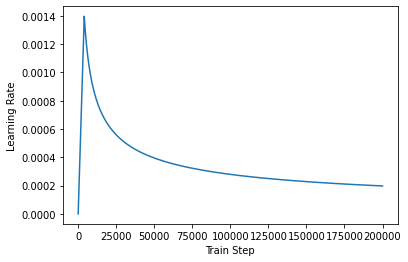

In [171]:
sample_learning_rate = CustomSchedule(d_model=128)

plt.plot(sample_learning_rate(tf.range(200000, dtype=tf.float32)))
plt.ylabel("Learning Rate")
plt.xlabel("Train Step")

In [172]:
learning_rate = CustomSchedule(D_MODEL)

optimizer = tf.keras.optimizers.Adam(
    learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

def accuracy(y_true, y_pred):
  y_true = tf.reshape(y_true, shape=(-1, MAX_LENGTH - 1))
  return tf.keras.metrics.sparse_categorical_accuracy(y_true, y_pred)

model.compile(optimizer=optimizer, loss=loss_function, metrics=[accuracy])
print("슝=3")

슝=3


In [173]:
EPOCHS = 10
model.fit(dataset, epochs=EPOCHS, verbose=1)

Epoch 1/10
185/185 [==============================] - 15s 54ms/step - loss: 0.4134 - accuracy: 0.0819
Epoch 2/10
185/185 [==============================] - 10s 54ms/step - loss: 0.4004 - accuracy: 0.0840
Epoch 3/10
185/185 [==============================] - 10s 54ms/step - loss: 0.3825 - accuracy: 0.0868
Epoch 4/10
185/185 [==============================] - 10s 54ms/step - loss: 0.3584 - accuracy: 0.0903
Epoch 5/10
185/185 [==============================] - 10s 54ms/step - loss: 0.3275 - accuracy: 0.0950
Epoch 6/10
185/185 [==============================] - 10s 54ms/step - loss: 0.2923 - accuracy: 0.0998
Epoch 7/10
185/185 [==============================] - 10s 54ms/step - loss: 0.2533 - accuracy: 0.1058
Epoch 8/10
185/185 [==============================] - 10s 54ms/step - loss: 0.2134 - accuracy: 0.1119
Epoch 9/10
185/185 [==============================] - 10s 54ms/step - loss: 0.1750 - accuracy: 0.1179
Epoch 10/10
185/185 [==============================] - 10s 54ms/step - loss: 0.138

# STEP 5. 모델 평가

In [174]:
def decoder_inference(sentence):
  sentence = preprocess_sentence(sentence)

  # 입력된 문장을 정수 인코딩 후, 시작 토큰과 종료 토큰을 앞뒤로 추가.
  # ex) Where have you been? → [[8331   86   30    5 1059    7 8332]]
  sentence = tf.expand_dims(
      START_TOKEN + tokenizer.encode(sentence) + END_TOKEN, axis=0)

  # 디코더의 현재까지의 예측한 출력 시퀀스가 지속적으로 저장되는 변수.
  # 처음에는 예측한 내용이 없음으로 시작 토큰만 별도 저장. ex) 8331
  output_sequence = tf.expand_dims(START_TOKEN, 0)

  # 디코더의 인퍼런스 단계
  for i in range(MAX_LENGTH):
    # 디코더는 최대 MAX_LENGTH의 길이만큼 다음 단어 예측을 반복합니다.
    predictions = model(inputs=[sentence, output_sequence], training=False)
    predictions = predictions[:, -1:, :]

    # 현재 예측한 단어의 정수
    predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)

    # 만약 현재 예측한 단어가 종료 토큰이라면 for문을 종료
    if tf.equal(predicted_id, END_TOKEN[0]):
      break

    # 예측한 단어들은 지속적으로 output_sequence에 추가됩니다.
    # 이 output_sequence는 다시 디코더의 입력이 됩니다.
    output_sequence = tf.concat([output_sequence, predicted_id], axis=-1)

  return tf.squeeze(output_sequence, axis=0)
print("슝=3")

슝=3


In [175]:
def sentence_generation(sentence):
  # 입력 문장에 대해서 디코더를 동작 시켜 예측된 정수 시퀀스를 리턴받습니다.
  prediction = decoder_inference(sentence)

  # 정수 시퀀스를 다시 텍스트 시퀀스로 변환합니다.
  predicted_sentence = tokenizer.decode(
      [i for i in prediction if i < tokenizer.vocab_size])

  print('입력 : {}'.format(sentence))
  print('출력 : {}'.format(predicted_sentence))

  return predicted_sentence
print("슝=3")

슝=3


In [176]:
sentence_generation("점심 드셨나요?")

입력 : 점심 드셨나요?
출력 : 원하는 것을 당당하게 말하세요


'원하는 것을 당당하게 말하세요'

In [177]:
sentence_generation("안녕하세요")

입력 : 안녕하세요
출력 : 안녕하세요


'안녕하세요'

# STEP 6. 모델 배포 및 API self-hosting

In [178]:
# 모델 저장 경로 설정 (원하는 경로로 변경 가능)
MODEL_SAVE_PATH = './chatbot_model'

# 모델을 SavedModel 형식으로 저장
model.save(MODEL_SAVE_PATH, save_format='tf')

print(f"슝=3 모델이 {MODEL_SAVE_PATH}에 저장되었습니다.")

INFO:tensorflow:Assets written to: ./chatbot_model/assets


INFO:tensorflow:Assets written to: ./chatbot_model/assets


슝=3 모델이 ./chatbot_model에 저장되었습니다.
